# Notebook 3e — RF con CV por animal: Score lesional (regresión) **con explotación**
### Tuberculosis bovina

Target: **Score_lesional** (ordinal 0,1,2,4,5).
Pipeline de regresión con Random Forest, CV por animal, incluyendo **Expl como covariable
categórica fija** junto a los biomarcadores.

> **Pregunta de investigación:** ¿añade la explotación capacidad predictiva adicional
> a los biomarcadores para predecir la severidad lesional?

**Comparar con:**
- *Notebook 2e* (CV sin expl): señal de biomarcadores sin info de granja.
- *Este notebook (3e)*: señal de biomarcadores **condicionada a la granja conocida**.

## 1. Setup e importaciones

In [6]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.base import clone
from sklearn.model_selection import RepeatedKFold, KFold
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from scipy.stats import spearmanr as scipy_spearmanr
import shap
import tb_utils as tb

PALETTE = tb.set_plot_style()
tb.set_seeds(tb.SEED)

import os

DATA = "../BD.csv"
df = tb.clean(tb.load_raw(DATA))

d = tb.target_subset(df, "Score_lesional")
d = tb.drop_sparse_rows(d)

EXPL_COL = tb.GROUP_COL
FEATURES_BIO = tb.MODEL_FEATURES
FEATURES_ALL = tb.MODEL_FEATURES + [EXPL_COL]

NUM_3E = tb.NUM_FEATURES
#remove

CAT_3E = tb.CAT_FEATURES + [EXPL_COL]
print(CAT_3E)

#vamos a trabajar sólo con las siguientes feaures

FEATURES_ALL = ["VITAMINA_D", "CALCIO", "PIROPLASMA_Q_log", "EDAD", "ANAPLASMA", "RAZA2"] +[EXPL_COL]

X_all = d[FEATURES_ALL].copy()
y     = d["Score_lesional"].astype(float).values
g     = d[EXPL_COL].values

print(f"Dataset: n={len(y)}")
print(f"Features biomarcadores ({len(FEATURES_BIO)}): {FEATURES_BIO}")
print(f"Covariable adicional: {EXPL_COL} — niveles: {sorted(d[EXPL_COL].unique())}")
print()
print("Distribución de Score_lesional:")
print(pd.Series(y).value_counts().sort_index())
print(f"\nMedia = {y.mean():.3f}  |  Std = {y.std():.3f}")
print(f"Baseline RMSE = std(y) (modelo nulo) = {y.std():.3f}")

drop_sparse_rows: 3 fila(s) eliminada(s) (>4 NaN en features). n restante = 103.
['RAZA2', 'Expl']
Dataset: n=103
Features biomarcadores (8): ['VITAMINA_D', 'CALCIO', 'PIROPLASMA_Q_log', 'EDAD', 'PIROPLASMA', 'THEILERIA', 'ANAPLASMA', 'RAZA2']
Covariable adicional: Expl — niveles: ['VA32D', 'VC30D', 'VC94C', 'WZ72B']

Distribución de Score_lesional:
0.0    40
1.0    22
2.0    15
4.0     8
5.0    18
Name: count, dtype: int64

Media = 1.689  |  Std = 1.885
Baseline RMSE = std(y) (modelo nulo) = 1.885


## 2. Random Forest (regresión) y estrategia de validación cruzada

**CV por animal con Expl como feature fija (RepeatedKFold, 5×10):**
- Sin estratificación (target ordinal/continuo).
- `Expl` entra como feature categórica (OHE); la selección hacia atrás opera solo sobre biomarcadores.
- Métricas: **Spearman r** (robusta a outliers), **R²**, **RMSE**.

In [7]:
def make_rf_reg(n_estimators=100, min_samples_leaf=5):
    return RandomForestRegressor(
        n_estimators=n_estimators,
        max_depth=None,
        min_samples_leaf=min_samples_leaf,
        max_features="sqrt",
        random_state=tb.SEED,
        n_jobs=-1,
        oob_score=True,
    )

def make_pipe_3e(feature_list, n_estimators=100):
    """Pipeline con Expl como covariable categórica fija (regresión)."""
    num_f = [f for f in feature_list if f in NUM_3E]
    cat_f = [f for f in feature_list if f in CAT_3E]
    prep  = tb.make_preprocessor(numeric=num_f, categorical=cat_f, scale=False)
    return Pipeline([("prep", prep), ("clf", make_rf_reg(n_estimators=n_estimators))])

CV_OUTER_E = RepeatedKFold(n_splits=5, n_repeats=10, random_state=tb.SEED)
CV_SEL_E   = RepeatedKFold(n_splits=5, n_repeats=3,  random_state=tb.SEED)

def cv_metrics_3e(bio_features, X, y, cv=None, detailed=False, n_estimators=100):
    """Spearman r, R² y RMSE con CV por animal. Expl siempre incluida."""
    if cv is None:
        cv = RepeatedKFold(n_splits=5, n_repeats=10, random_state=tb.SEED)
    feats = list(bio_features) + ([EXPL_COL] if EXPL_COL not in bio_features else [])
    Xs = X[feats]
    pipe_tmpl = make_pipe_3e(feats, n_estimators)
    rows = []
    for tr, te in cv.split(Xs, y):
        pf = clone(pipe_tmpl)
        pf.fit(Xs.iloc[tr], y[tr])
        pred = pf.predict(Xs.iloc[te])
        sp   = scipy_spearmanr(y[te], pred).correlation
        r2   = r2_score(y[te], pred)
        rmse = float(np.sqrt(mean_squared_error(y[te], pred)))
        rows.append(dict(spearman=sp, r2=r2, rmse=rmse))
    df_r = pd.DataFrame(rows)
    if detailed:
        return df_r
    return df_r.spearman.mean(), df_r.spearman.std()

print("Evaluación baseline RF regresión (todos los biomarcadores + Expl, CV por animal):")
base_m, base_s = cv_metrics_3e(FEATURES_ALL, X_all, y)
print(f"  Spearman r = {base_m:.3f} ± {base_s:.3f}")
print(f"  Modelo nulo (r=0) = referencia")

Evaluación baseline RF regresión (todos los biomarcadores + Expl, CV por animal):
  Spearman r = 0.430 ± 0.214
  Modelo nulo (r=0) = referencia


## 3. Pipeline de selección de características

Eliminación hacia atrás sobre **biomarcadores** con `Expl` siempre presente:
1. Importancia de permutación sobre modelo completo → ranking.
2. Eliminación hacia atrás; `Expl` fija en cada paso.
3. Subconjunto más pequeño con Spearman ≥ máx − 1·DE.

Paso 1: Ajustando RF regresión completo (biomarcadores + Expl)...
OOB Score R² (en muestra): 0.336

Ranking importancia de permutación (R², biomarcadores + Expl):
                 pretty  imp_mean  imp_std
                   Expl    0.4876   0.0820
             Vitamina D    0.0975   0.0147
log(1+Carga piroplasma)    0.0869   0.0146
                 Calcio    0.0706   0.0098
     Anaplasma spp. (+)    0.0457   0.0125
            Edad (años)    0.0340   0.0076
                   Raza    0.0113   0.0030


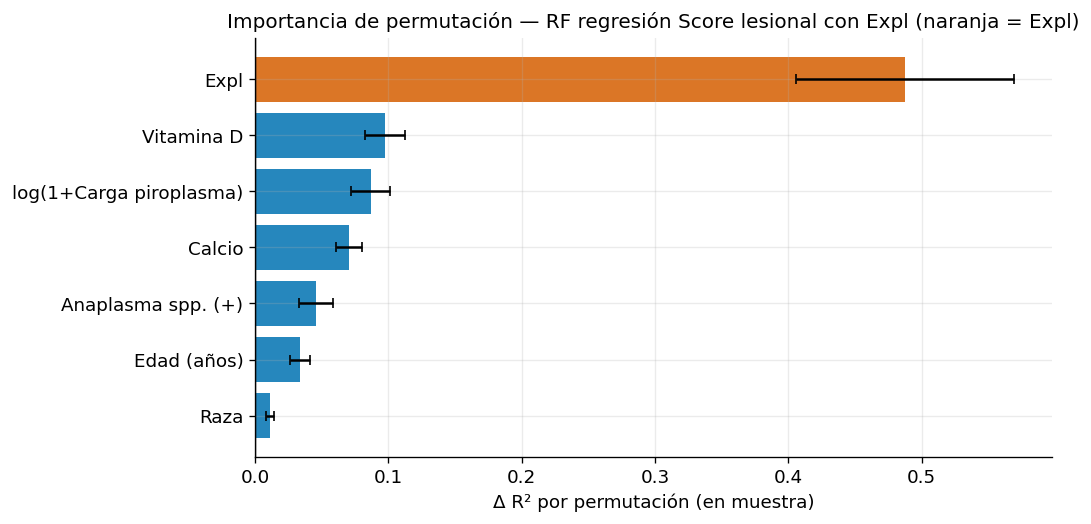

In [9]:
print("Paso 1: Ajustando RF regresión completo (biomarcadores + Expl)...")
full_pipe = make_pipe_3e(FEATURES_ALL).fit(X_all, y)
print(f"OOB Score R² (en muestra): {full_pipe.named_steps['clf'].oob_score_:.3f}")

pi = permutation_importance(
    full_pipe, X_all, y,
    scoring="r2",
    n_repeats=50,
    random_state=tb.SEED,
    n_jobs=-1,
)
imp_df = pd.DataFrame({
    "feature":  FEATURES_ALL,
    "imp_mean": pi.importances_mean,
    "imp_std":  pi.importances_std,
}).sort_values("imp_mean", ascending=False).reset_index(drop=True)
imp_df["pretty"] = imp_df.feature.map(lambda f: tb.PRETTY.get(f, f))

print("\nRanking importancia de permutación (R², biomarcadores + Expl):")
print(imp_df[["pretty", "imp_mean", "imp_std"]].round(4).to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 4.5))
order = imp_df.sort_values("imp_mean")
colors_bar = [PALETTE[1] if f == EXPL_COL else PALETTE[0] for f in order.feature]
ax.barh(order.pretty, order.imp_mean, xerr=order.imp_std, color=colors_bar, capsize=3, alpha=0.85)
ax.axvline(0, color="k", lw=0.8)
ax.set_xlabel("Δ R² por permutación (en muestra)")
ax.set_title("Importancia de permutación — RF regresión Score lesional con Expl (naranja = Expl)")
plt.tight_layout(); plt.savefig("figures/fig_03e_perm_importance_full.png"); plt.show()

In [11]:
bio_imp = imp_df[imp_df.feature != EXPL_COL].sort_values("imp_mean", ascending=True)
elim_order = bio_imp["feature"].tolist()
print(f"Orden de eliminación de biomarcadores: {elim_order}")
print(f"Covariable fija: {EXPL_COL}\n")
print("Paso 2: Eliminación hacia atrás de biomarcadores (Expl siempre presente)...\n")

current_bio = FEATURES_ALL.copy()
history = []

m0, s0 = cv_metrics_3e(current_bio, X_all, y, cv=CV_SEL_E)
history.append({"n": len(current_bio), "bio_features": current_bio.copy(),
                "removed": "—(baseline)", "mean": m0, "std": s0})
print(f"  {len(current_bio):2d} bio + Expl [baseline] Spearman={m0:.3f}±{s0:.3f}")

for feat in elim_order:
    if feat not in current_bio or len(current_bio) <= 1: break
    test_bio = [f for f in current_bio if f != feat]
    m, s = cv_metrics_3e(test_bio, X_all, y, cv=CV_SEL_E)
    history.append({"n": len(test_bio), "bio_features": test_bio.copy(),
                    "removed": feat, "mean": m, "std": s})
    print(f"  {len(test_bio):2d} bio + Expl [-{feat:20s}] Spearman={m:.3f}±{s:.3f}  Δ={m-m0:+.3f}")
    current_bio = test_bio

hist_df = pd.DataFrame(history)

Orden de eliminación de biomarcadores: ['RAZA2', 'EDAD', 'ANAPLASMA', 'CALCIO', 'PIROPLASMA_Q_log', 'VITAMINA_D']
Covariable fija: Expl

Paso 2: Eliminación hacia atrás de biomarcadores (Expl siempre presente)...



   7 bio + Expl [baseline] Spearman=0.382±0.266
   6 bio + Expl [-RAZA2               ] Spearman=0.380±0.285  Δ=-0.002
   5 bio + Expl [-EDAD                ] Spearman=0.406±0.281  Δ=+0.024
   4 bio + Expl [-ANAPLASMA           ] Spearman=0.386±0.272  Δ=+0.004
   3 bio + Expl [-CALCIO              ] Spearman=0.383±0.267  Δ=+0.001
   2 bio + Expl [-PIROPLASMA_Q_log    ] Spearman=0.369±0.291  Δ=-0.014
   1 bio + Expl [-VITAMINA_D          ] Spearman=0.423±0.210  Δ=+0.041


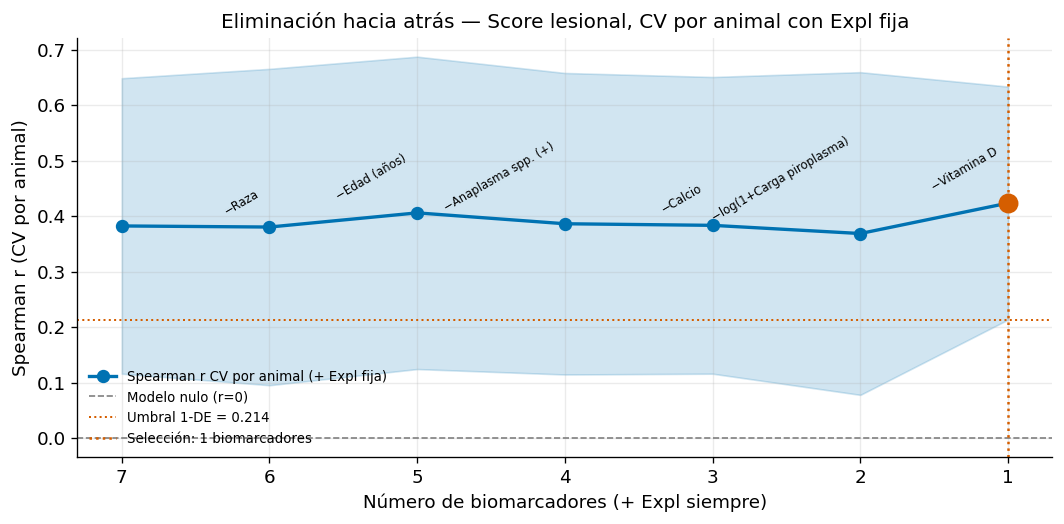


Biomarcadores SELECCIONADOS (1): ['Expl']


In [ ]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(hist_df.n, hist_df["mean"], "o-", color=PALETTE[0], lw=2, ms=7,
        label="Spearman r CV por animal (+ Expl fija)")
ax.fill_between(hist_df.n, hist_df["mean"]-hist_df["std"], hist_df["mean"]+hist_df["std"],
                alpha=0.18, color=PALETTE[0])
ax.axhline(0, ls="--", color="grey", lw=1, label="Modelo nulo (r=0)")

best_idx     = hist_df["mean"].idxmax()
best_mu      = hist_df["mean"].max()
best_sd      = hist_df.loc[best_idx, "std"]
threshold    = best_mu - best_sd
parsimonious = hist_df[hist_df["mean"] >= threshold].sort_values("n").iloc[0]

ax.axhline(threshold, ls=":", color=PALETTE[1], lw=1.2, label=f"Umbral 1-DE = {threshold:.3f}")
ax.axvline(parsimonious.n, color=PALETTE[1], ls=":", lw=1.5,
           label=f"Selección: {int(parsimonious.n)} biomarcadores")
ax.scatter([parsimonious.n], [parsimonious["mean"]], color=PALETTE[1], s=120, zorder=5)

for _, row in hist_df.iterrows():
    label = tb.PRETTY.get(row.removed, row.removed) if row.removed != "—(baseline)" else ""
    if label:
        ax.annotate(f"−{label}", (row.n, row["mean"]),
                    textcoords="offset points", xytext=(-5, 8), fontsize=7, ha="right", rotation=30)

ax.set_xlabel("Número de biomarcadores (+ Expl siempre)")
ax.set_ylabel("Spearman r (CV por animal)")
ax.set_title("Eliminación hacia atrás — Score lesional, CV por animal con Expl fija")
ax.legend(fontsize=8); ax.invert_xaxis()
plt.tight_layout(); plt.savefig("figures/fig_03e_feature_selection_curve.png"); plt.show()

SELECTED_BIO_3E = list(parsimonious.bio_features)
print(f"\nBiomarcadores SELECCIONADOS ({len(SELECTED_BIO_3E)}): {SELECTED_BIO_3E}")

In [ ]:
"""def _cv_r2_3e(bio_features, X, y, cv):
    feats = list(bio_features) + [EXPL_COL]
    Xs = X[feats]
    pipe_tmpl = make_pipe_3e(feats)
    r2s = []
    for tr, te in cv.split(Xs, y):
        pf = clone(pipe_tmpl)
        pf.fit(Xs.iloc[tr], y[tr])
        r2s.append(r2_score(y[te], pf.predict(Xs.iloc[te])))
    return np.mean(r2s), np.std(r2s)

print("Calculando R² para cada subconjunto (≈1 min)...")
r2_means, r2_stds = [], []
for _, row in hist_df.iterrows():
    m, s = _cv_r2_3e(row["bio_features"], X_all, y, CV_SEL_E)
    r2_means.append(m); r2_stds.append(s)
    print(f"  {int(row.n):2d} bio [-{row['removed']:20s}] R²={m:.3f}±{s:.3f}")

hist_df = hist_df.assign(r2_mean=r2_means, r2_std=r2_stds)

fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)
x = np.arange(len(hist_df))
labels = []
for _, row in hist_df.iterrows():
    if row["removed"] == "—(baseline)":
        lbl = f"baseline\n({int(row.n)} bio)"
    else:
        lbl = f"−{tb.PRETTY.get(row['removed'], row['removed'])}\n({int(row.n)} bio)"
    labels.append(lbl)

ax1 = axes[0]
ax1.plot(x, hist_df["mean"], "o-", color=PALETTE[0], lw=2, ms=7, label="Spearman r")
ax1.fill_between(x, hist_df["mean"]-hist_df["std"], hist_df["mean"]+hist_df["std"], alpha=0.18, color=PALETTE[0])
ax1.axhline(0, ls="--", color="grey", lw=1, label="Modelo nulo (r=0)")
ax1.set_ylabel("Spearman r"); ax1.legend(fontsize=8); ax1.grid(axis="y", alpha=0.3)
ax1.set_title("Eliminación hacia atrás — Spearman r y R² (CV por animal, Expl fija)")

ax2 = axes[1]
ax2.plot(x, hist_df["r2_mean"], "s-", color=PALETTE[1], lw=2, ms=7, label="R²")
ax2.fill_between(x, hist_df["r2_mean"]-hist_df["r2_std"], hist_df["r2_mean"]+hist_df["r2_std"], alpha=0.18, color=PALETTE[1])
ax2.axhline(0, ls="--", color="grey", lw=1, label="Modelo nulo (R²=0)")
ax2.set_ylabel("R²"); ax2.legend(fontsize=8); ax2.grid(axis="y", alpha=0.3)
ax2.set_xticks(x); ax2.set_xticklabels(labels, fontsize=8, ha="center")
ax2.set_xlabel("Biomarcador eliminado (N restantes, Expl siempre presente)")
plt.tight_layout()
plt.savefig("figures/fig_03e_feature_selection_metrics.png", bbox_inches="tight")
plt.show()
"""

Calculando R² para cada subconjunto (≈1 min)...


ValueError: Selected columns, ['RAZA2', 'Expl', 'Expl'], are not unique in dataframe

## 4. Evaluación del modelo final (CV por animal, 5×10)

Modelo final — features (5): ['VITAMINA_D', 'CALCIO', 'PIROPLASMA_Q_log', 'ANAPLASMA', 'Expl']

Métricas CV por animal (5×10, con Expl) — Score lesional regresión:
  Spearman = 0.453 ± 0.207
  R²       = 0.271 ± 0.189
  RMSE     = 1.543 ± 0.171
  Baseline RMSE (modelo nulo) = 1.885


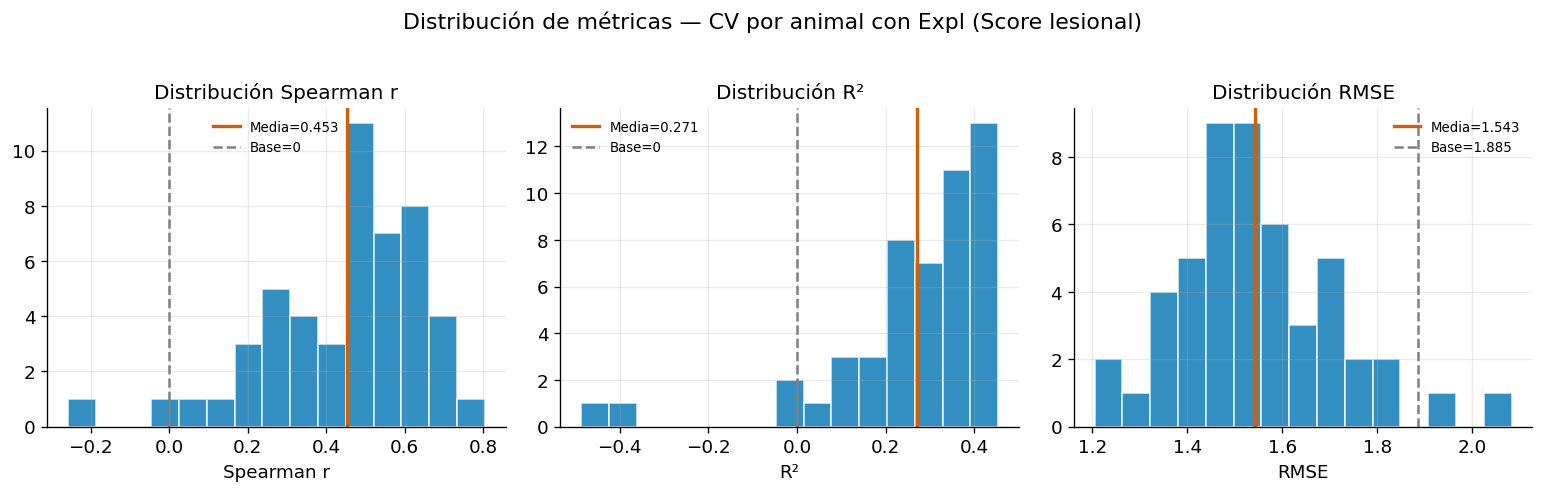

In [15]:
SELECTED_BIO_3E = ['VITAMINA_D', 'CALCIO', 'PIROPLASMA_Q_log','ANAPLASMA']  # ajustar si procede
FEATS_FINAL_3E = SELECTED_BIO_3E + [EXPL_COL]
Xs = X_all[FEATS_FINAL_3E].copy()
print(f"Modelo final — features ({len(FEATS_FINAL_3E)}): {FEATS_FINAL_3E}\n")

detailed_df = cv_metrics_3e(SELECTED_BIO_3E, X_all, y, cv=CV_OUTER_E, detailed=True, n_estimators=700)
m = detailed_df.mean(); s = detailed_df.std()

print("Métricas CV por animal (5×10, con Expl) — Score lesional regresión:")
print(f"  Spearman = {m.spearman:.3f} ± {s.spearman:.3f}")
print(f"  R²       = {m.r2:.3f} ± {s.r2:.3f}")
print(f"  RMSE     = {m.rmse:.3f} ± {s.rmse:.3f}")
print(f"  Baseline RMSE (modelo nulo) = {y.std():.3f}")

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, col, title in zip(axes, ["spearman", "r2", "rmse"], ["Spearman r", "R²", "RMSE"]):
    ax.hist(detailed_df[col].dropna(), bins=15, color=PALETTE[0], alpha=0.8, edgecolor="white")
    ax.axvline(detailed_df[col].mean(), color=PALETTE[1], lw=2,
               label=f"Media={detailed_df[col].mean():.3f}")
    if col in ("spearman", "r2"):
        ax.axvline(0, color="grey", ls="--", lw=1.5, label="Base=0")
    if col == "rmse":
        ax.axvline(y.std(), color="grey", ls="--", lw=1.5, label=f"Base={y.std():.3f}")
    ax.set_xlabel(title); ax.set_title(f"Distribución {title}"); ax.legend(fontsize=8)
plt.suptitle("Distribución de métricas — CV por animal con Expl (Score lesional)", y=1.02)
plt.tight_layout(); plt.savefig("figures/fig_03e_metrics_dist.png", bbox_inches="tight"); plt.show()

## 5. Interpretabilidad global — SHAP

Las columnas `Expl_*` muestran el efecto granja en la predicción del Score lesional.
Los valores SHAP de biomarcadores reflejan su contribución **condicionada a la granja**.

In [16]:
FINAL_3E = make_pipe_3e(FEATS_FINAL_3E, n_estimators=500).fit(Xs, y)
print(f"OOB Score R² (en muestra): {FINAL_3E.named_steps['clf'].oob_score_:.3f}")

prep_3e  = FINAL_3E.named_steps["prep"]
clf_3e   = FINAL_3E.named_steps["clf"]
Xt_3e    = prep_3e.transform(Xs)
names_3e = list(prep_3e.get_feature_names_out())

explainer_3e = shap.TreeExplainer(clf_3e)
sv_3e = np.asarray(explainer_3e.shap_values(Xt_3e))
if sv_3e.ndim == 3:
    sv_3e = sv_3e[:, :, 0]

exp_val_3e = float(np.asarray(explainer_3e.expected_value).ravel()[0])

print(f"Features tras preprocesamiento : {names_3e}")
print(f"SHAP shape: {sv_3e.shape}  |  expected_value: {exp_val_3e:.4f}")

OOB Score R² (en muestra): 0.378
Features tras preprocesamiento : ['VITAMINA_D', 'CALCIO', 'PIROPLASMA_Q_log', 'ANAPLASMA', 'Expl_VA32D', 'Expl_VC30D', 'Expl_VC94C', 'Expl_WZ72B']
SHAP shape: (103, 8)  |  expected_value: 1.6920


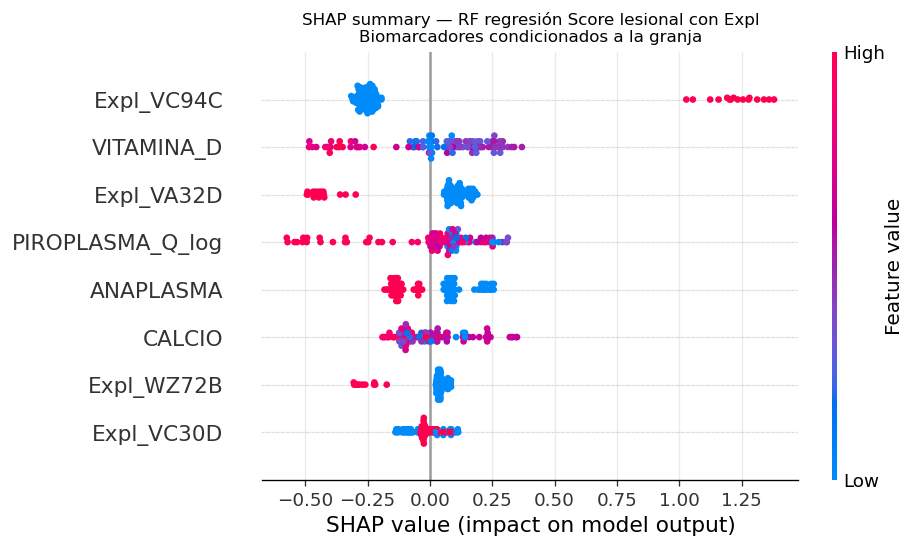

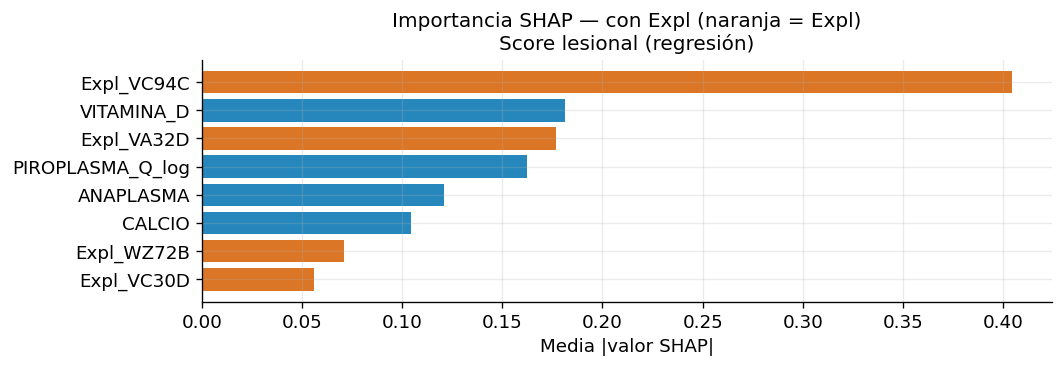

In [17]:
plt.figure(figsize=(9, max(4, 0.5 * len(names_3e))))
shap.summary_plot(sv_3e, Xt_3e, feature_names=names_3e, show=False, max_display=len(names_3e))
plt.title("SHAP summary — RF regresión Score lesional con Expl\n"
          "Biomarcadores condicionados a la granja", fontsize=10)
plt.tight_layout(); plt.savefig("figures/fig_03e_shap_summary.png", bbox_inches="tight"); plt.show()

mean_abs_3e = np.abs(sv_3e).mean(0)
si_3e = pd.DataFrame({"feature": names_3e, "mean_abs": mean_abs_3e}).sort_values("mean_abs")
colors_shap = [PALETTE[1] if "Expl" in f else PALETTE[0] for f in si_3e.feature]
fig, ax = plt.subplots(figsize=(9, max(3, 0.4 * len(names_3e))))
ax.barh(si_3e.feature, si_3e.mean_abs, color=colors_shap, alpha=0.85)
ax.set_xlabel("Media |valor SHAP|")
ax.set_title("Importancia SHAP — con Expl (naranja = Expl)\nScore lesional (regresión)")
plt.tight_layout(); plt.savefig("figures/fig_03e_shap_importance.png"); plt.show()

In [18]:
shap.initjs()
order = np.argsort(FINAL_3E.predict(Xs))
fp = shap.force_plot(exp_val_3e, sv_3e[order], Xt_3e[order], feature_names=names_3e)
shap.save_html("figures/fig_03e_shap_force_plot_global.html", fp)
display(fp)

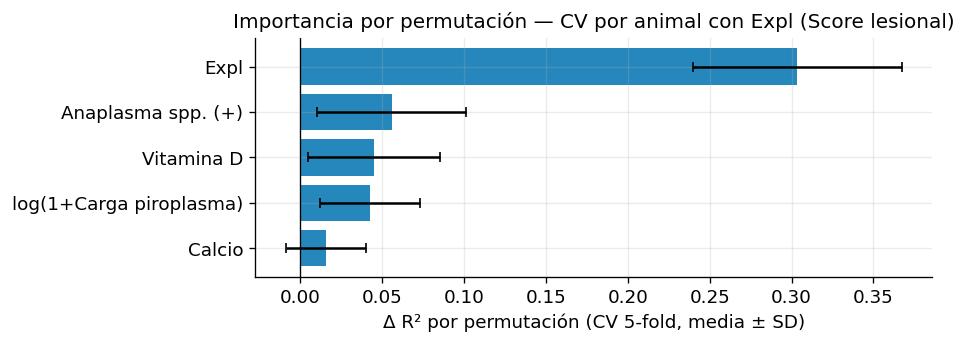

Estabilidad Spearman entre folds: 0.550


In [19]:
from scipy.stats import spearmanr
imp_runs_3e = []
cv_stab = KFold(n_splits=5, shuffle=True, random_state=tb.SEED)
for tr, te in cv_stab.split(Xs, y):
    pf = clone(make_pipe_3e(FEATS_FINAL_3E)).fit(Xs.iloc[tr], y[tr])
    pi_f = permutation_importance(pf, Xs.iloc[te], y[te],
                                  scoring="r2", n_repeats=20,
                                  random_state=tb.SEED)
    imp_runs_3e.append(pd.Series(pi_f.importances_mean, index=FEATS_FINAL_3E))

imp_mat_3e = pd.concat(imp_runs_3e, axis=1)
imp_ord_3e = imp_mat_3e.mean(axis=1).sort_values().index
R = imp_mat_3e.fillna(0)
cors = [spearmanr(R.iloc[:, i], R.iloc[:, j]).correlation
        for i in range(R.shape[1]) for j in range(i + 1, R.shape[1])]

fig, ax = plt.subplots(figsize=(8, max(3, 0.45 * len(FEATS_FINAL_3E))))
ax.barh([tb.PRETTY.get(f, f) for f in imp_ord_3e],
        imp_mat_3e.mean(axis=1)[imp_ord_3e],
        xerr=imp_mat_3e.std(axis=1)[imp_ord_3e],
        color=PALETTE[0], capsize=3, alpha=0.85)
ax.axvline(0, color="k", lw=0.8)
ax.set_xlabel("Δ R² por permutación (CV 5-fold, media ± SD)")
ax.set_title("Importancia por permutación — CV por animal con Expl (Score lesional)")
plt.tight_layout(); plt.savefig("figures/fig_03e_perm_importance_cv.png"); plt.show()
print(f"Estabilidad Spearman entre folds: {np.nanmean(cors):.3f}")

## 6. Partial Dependence Plots + ICE

Features continuas para PDP/ICE: ['VITAMINA_D', 'CALCIO', 'PIROPLASMA_Q_log']


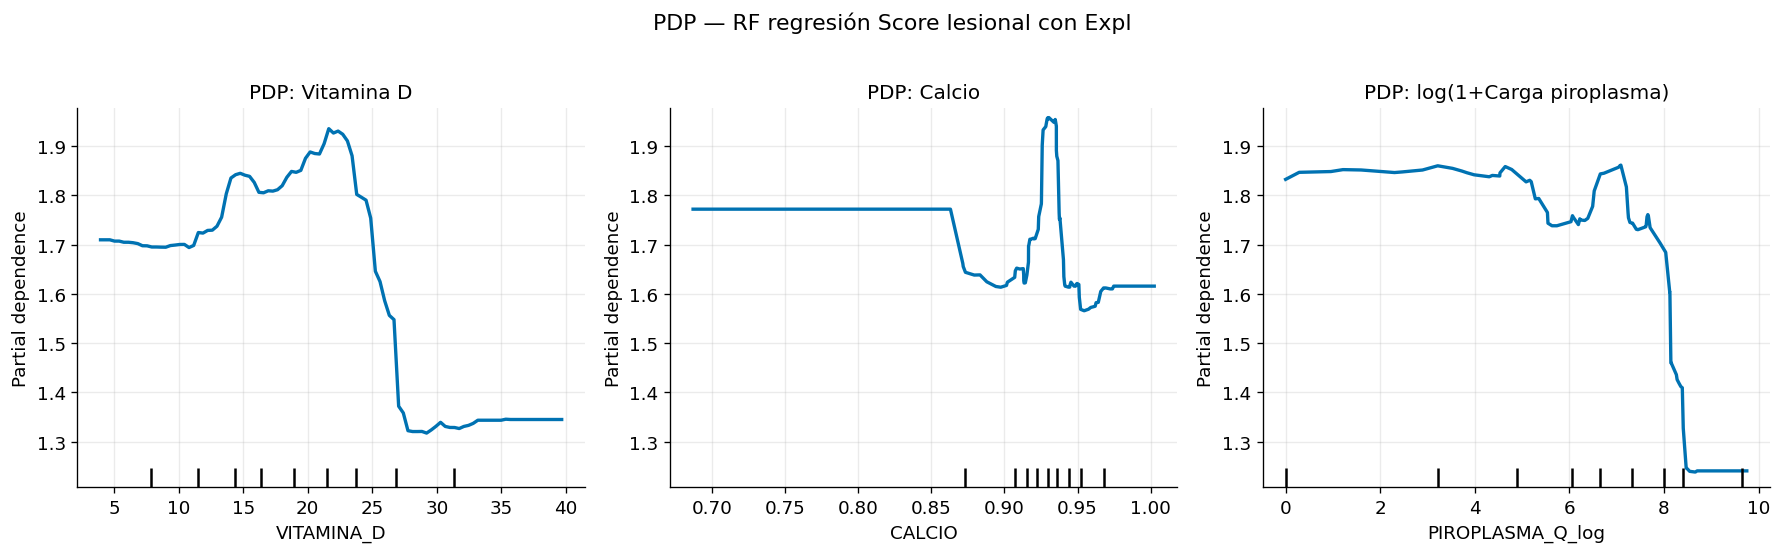

In [ ]:
CONT_3E = [f for f in FEATS_FINAL_3E if f in tb.NUM_FEATURES and Xs[f].nunique() > 5]
if not CONT_3E:
    CONT_3E = [f for f in FEATS_FINAL_3E if f in tb.NUM_FEATURES]

print(f"Features continuas para PDP/ICE: {CONT_3E}")
if CONT_3E:
    n_c = len(CONT_3E)
    fig, axes = plt.subplots(1, n_c, figsize=(5 * n_c, 4.5))
    if n_c == 1: axes = [axes]
    PartialDependenceDisplay.from_estimator(FINAL_3E, Xs, CONT_3E, kind="average",
        ax=axes, line_kw={"color": PALETTE[0], "lw": 2})
    for ax, f in zip(axes, CONT_3E):
        ax.set_title(f"PDP: {tb.PRETTY.get(f, f)}")
    plt.suptitle("PDP — RF regresión Score lesional con Expl", y=1.02)
    plt.tight_layout(); plt.savefig("figures/fig_03e_pdp.png", bbox_inches="tight"); plt.show()

    fig, axes = plt.subplots(1, n_c, figsize=(5 * n_c, 5))
    if n_c == 1: axes = [axes]
    PartialDependenceDisplay.from_estimator(FINAL_3E, Xs, CONT_3E, kind="both",
        ax=axes,
        ice_lines_kw={"color": "grey", "alpha": 0.2, "lw": 0.7},
        pd_line_kw={"color": PALETTE[0], "lw": 2.5},
        centered=True)
    for ax, f in zip(axes, CONT_3E):
        ax.set_title(f"ICE + PDP: {tb.PRETTY.get(f, f)}")
    plt.suptitle("ICE + PDP — RF regresión Score lesional con Expl", y=1.02)
    plt.tight_layout(); plt.savefig("figures/fig_03e_ice.png", bbox_inches="tight"); plt.show()

## 7. Accumulated Local Effects (ALE)

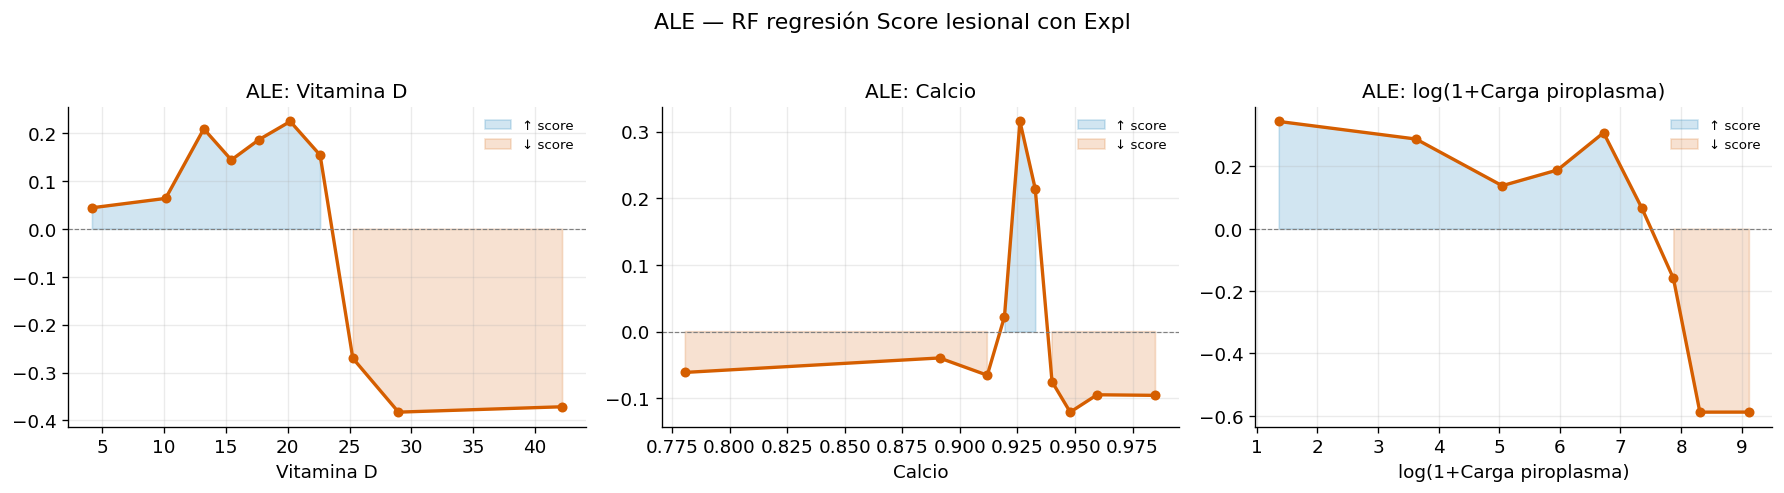

In [ ]:
def ale_1d_reg(model, X, feat, bins=10):
    x = X[feat].dropna().values
    q = np.quantile(x, np.linspace(0, 1, bins + 1)); q = np.unique(q)
    if len(q) < 3: return np.array([]), np.array([])
    eff, Xc = [], X.copy()
    for i in range(len(q) - 1):
        mask = (X[feat] >= q[i]) & (X[feat] <= q[i + 1])
        if mask.sum() == 0: eff.append(0.0); continue
        lo = Xc.loc[mask].copy(); lo[feat] = q[i]
        hi = Xc.loc[mask].copy(); hi[feat] = q[i + 1]
        eff.append((model.predict(hi) - model.predict(lo)).mean())
    ale = np.cumsum(eff); ale -= ale.mean()
    return (q[:-1] + q[1:]) / 2, ale

if CONT_3E:
    n_c = len(CONT_3E)
    fig, axes = plt.subplots(1, n_c, figsize=(5 * n_c, 4))
    if n_c == 1: axes = [axes]
    for ax, feat in zip(axes, CONT_3E):
        cx, ale = ale_1d_reg(FINAL_3E, Xs, feat)
        if len(cx) == 0: ax.set_title(f"ALE: {tb.PRETTY.get(feat,feat)}\n(insuf.)"); continue
        ax.plot(cx, ale, "o-", color=PALETTE[1], lw=2, ms=5)
        ax.axhline(0, color="grey", lw=0.7, ls="--")
        ax.fill_between(cx, 0, ale, where=(ale > 0), alpha=0.18, color=PALETTE[0], label="↑ score")
        ax.fill_between(cx, 0, ale, where=(ale < 0), alpha=0.18, color=PALETTE[1], label="↓ score")
        ax.set_title(f"ALE: {tb.PRETTY.get(feat,feat)}")
        ax.set_xlabel(tb.PRETTY.get(feat,feat)); ax.legend(fontsize=8)
    plt.suptitle("ALE — RF regresión Score lesional con Expl", y=1.02)
    plt.tight_layout(); plt.savefig("figures/fig_03e_ale.png", bbox_inches="tight"); plt.show()

## 8. SHAP waterfall — interpretabilidad local

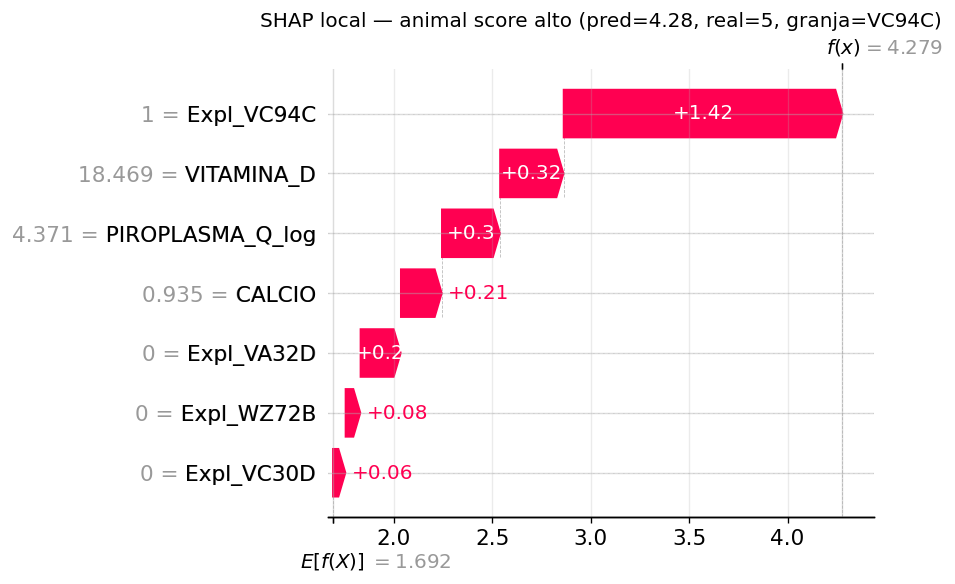

Animal 67: pred=4.28, Score real=5, granja=VC94C


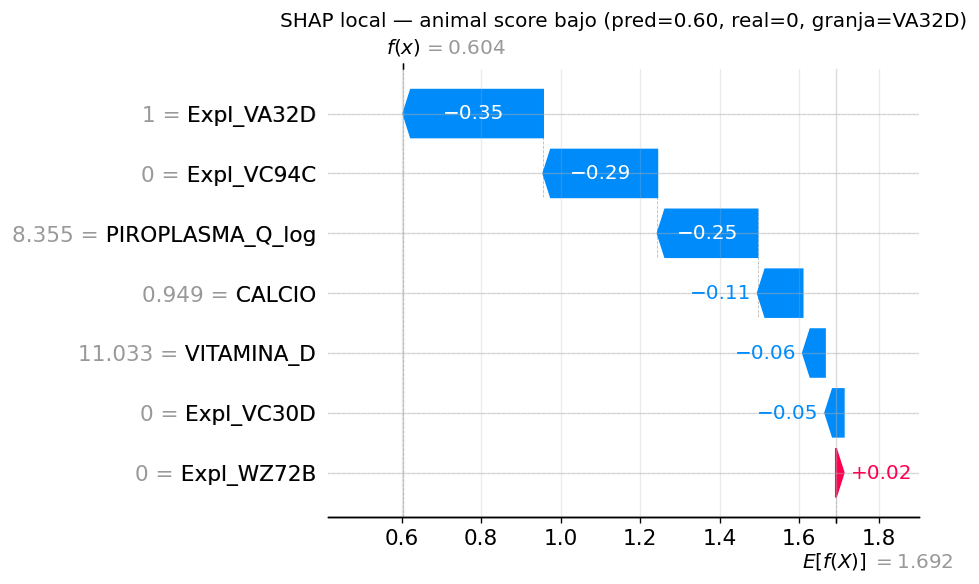

Animal 80: pred=0.60, Score real=0, granja=VA32D


In [ ]:
p_all_3e = FINAL_3E.predict(Xs)
idx_pos  = int(np.argmax(p_all_3e))
idx_neg  = int(np.argmin(p_all_3e))

shap_exp_3e = shap.Explanation(values=sv_3e, base_values=exp_val_3e,
                                data=Xt_3e, feature_names=names_3e)

for tag, idx in [("score_alto", idx_pos), ("score_bajo", idx_neg)]:
    farm_ref = g[idx]
    fig, _ = plt.subplots(figsize=(10, 4))
    shap.plots.waterfall(shap_exp_3e[idx], max_display=len(names_3e), show=False)
    plt.title(
        f"SHAP local — animal {tag.replace('_',' ')} "
        f"(pred={p_all_3e[idx]:.2f}, real={y[idx]:.0f}, granja={farm_ref})"
    )
    plt.tight_layout()
    plt.savefig(f"figures/fig_03e_waterfall_{tag}.png", bbox_inches="tight"); plt.show()
    print(f"Animal {idx}: pred={p_all_3e[idx]:.2f}, Score real={y[idx]:.0f}, granja={farm_ref}")

## 9. Contrafactuales (sobre biomarcadores, granja fija)

In [ ]:
def find_cf_reg(model, row_dict, feat, lo, hi, threshold, direction="above", n=500):
    for v in np.linspace(lo, hi, n):
        r = dict(row_dict); r[feat] = v
        pred = model.predict(pd.DataFrame([r]))[0]
        if direction == "above" and pred >= threshold: return v, pred
        if direction == "below" and pred <= threshold: return v, pred
    return None, None

threshold_cf = float(np.median(y))
high_row = Xs.iloc[idx_pos].copy()
low_row  = Xs.iloc[idx_neg].copy()

print("=" * 60)
print("CONTRAFACTUALES — biomarcadores (granja fija)")
print(f"Umbral = mediana(y) = {threshold_cf:.1f}")
print("=" * 60)

for tag, row, direction in [("SCORE ALTO", high_row, "below"),
                             ("SCORE BAJO", low_row, "above")]:
    pred = FINAL_3E.predict(pd.DataFrame([row]))[0]
    print(f"\nAnimal {tag} (pred={pred:.2f}, granja={row[EXPL_COL]}), objetivo → "
          f"{'por debajo' if direction=='below' else 'por encima'} de {threshold_cf:.1f}")
    for feat in CONT_3E:
        lo_v, hi_v = float(Xs[feat].min()), float(Xs[feat].max())
        cf_val, cf_pred = find_cf_reg(FINAL_3E, row.to_dict(), feat, lo_v, hi_v, threshold_cf, direction)
        cur = row[feat]
        if cf_val is not None:
            print(f"  {tb.PRETTY.get(feat,feat):30s}: actual={cur:.2f} → cf={cf_val:.2f} "
                  f"(Δ={cf_val-cur:+.2f}, pred_cf={cf_pred:.2f})")
        else:
            print(f"  {tb.PRETTY.get(feat,feat):30s}: actual={cur:.2f} → no alcanzable")

CONTRAFACTUALES — biomarcadores (granja fija)
Umbral = mediana(y) = 1.0

Animal SCORE ALTO (pred=4.28, granja=VC94C), objetivo → por debajo de 1.0
  Vitamina D                    : actual=18.47 → no alcanzable
  Calcio                        : actual=0.93 → no alcanzable
  log(1+Carga piroplasma)       : actual=4.37 → no alcanzable

Animal SCORE BAJO (pred=0.60, granja=VA32D), objetivo → por encima de 1.0
  Vitamina D                    : actual=11.03 → no alcanzable
  Calcio                        : actual=0.95 → no alcanzable
  log(1+Carga piroplasma)       : actual=8.35 → no alcanzable


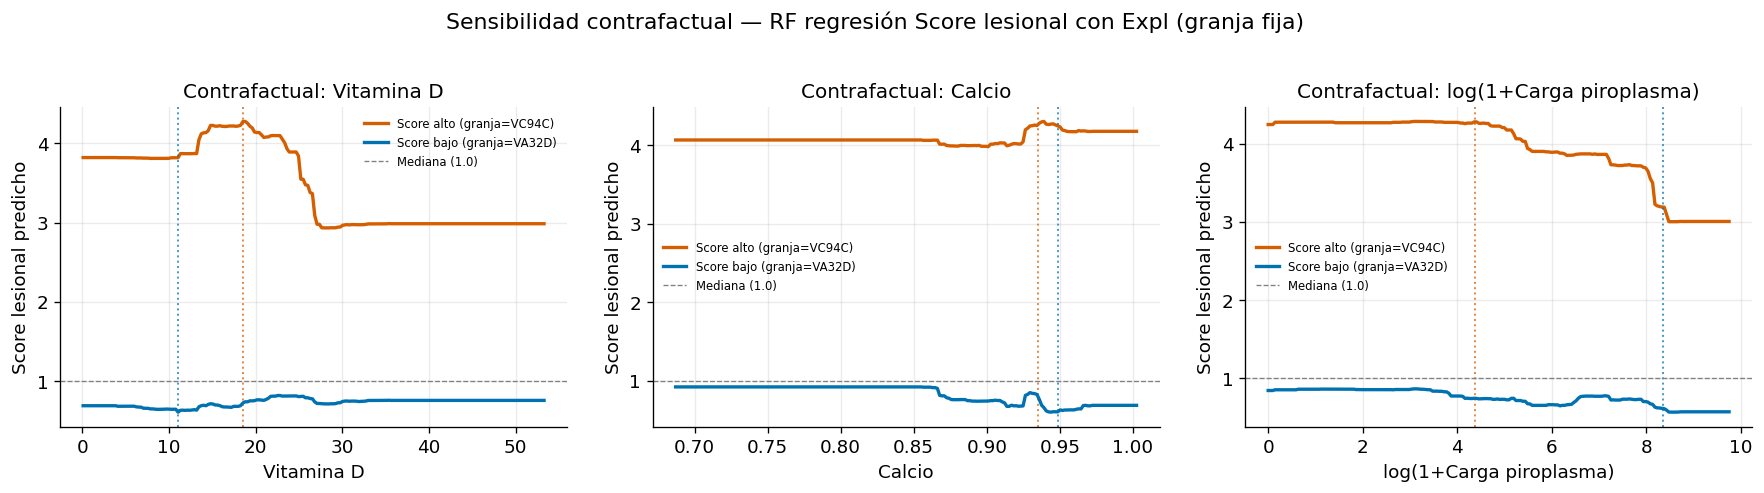

In [ ]:
if CONT_3E:
    n_c = len(CONT_3E)
    fig, axes = plt.subplots(1, n_c, figsize=(5 * n_c, 4))
    if n_c == 1: axes = [axes]
    for ax, feat in zip(axes, CONT_3E):
        lo_v, hi_v = float(Xs[feat].min()), float(Xs[feat].max())
        grid = np.linspace(lo_v, hi_v, 200)
        for tag, row, color in [("Score alto", high_row, PALETTE[1]),
                                 ("Score bajo", low_row, PALETTE[0])]:
            preds = [FINAL_3E.predict(pd.DataFrame([{**row.to_dict(), feat: v}]))[0] for v in grid]
            ax.plot(grid, preds, color=color, lw=2, label=f"{tag} (granja={row[EXPL_COL]})")
            ax.axvline(row[feat], color=color, ls=":", lw=1.2, alpha=0.7)
        ax.axhline(threshold_cf, color="grey", ls="--", lw=0.8,
                   label=f"Mediana ({threshold_cf:.1f})")
        ax.set_xlabel(tb.PRETTY.get(feat, feat))
        ax.set_ylabel("Score lesional predicho")
        ax.set_title(f"Contrafactual: {tb.PRETTY.get(feat,feat)}"); ax.legend(fontsize=7)
    plt.suptitle("Sensibilidad contrafactual — RF regresión Score lesional con Expl (granja fija)", y=1.02)
    plt.tight_layout(); plt.savefig("figures/fig_03e_cf_curves.png", bbox_inches="tight"); plt.show()

## 10. Síntesis y triangulación

### Tabla comparativa

| Métrica | Nb 2e — CV sin expl | **Nb 3e — CV + Expl fija** |
|---|---|---|
| Spearman r | — | **—** |
| R² | — | **—** |
| RMSE | — | **—** |
| Expl como feature | No | **Sí (OHE, siempre fija)** |

### Guía de interpretación

- **Si Spearman(3e) >> Spearman(2e):** la explotación aporta señal incremental para predecir
  el score lesional más allá de los biomarcadores solos; la granja explica parte de la
  variabilidad del score no capturada por los marcadores individuales.

- **Si Spearman(3e) ≈ Spearman(2e):** la identidad de la granja no añade valor predictivo
  para el score lesional; los biomarcadores capturan toda la señal disponible.

- **SHAP de Expl_*:** si las columnas de granja tienen SHAP elevado, el score lesional
  está fuertemente determinado por la granja (diferencias en cepa, exposición o manejo).